In [23]:
# Importing the Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [24]:
import plotly
import plotly.express as px
from plotly.subplots import make_subplots

In [25]:
# Loading the Data
tv_shows = pd.read_csv(r'C:\Users\Kamran\Git Repos\Machine-Learning-Projects\Best Streaming Service Analysis\Best Streaming Service Analysis Data.csv')

In [26]:
# Analyse the Top 5 rows of the data
tv_shows.head()

,Unnamed: 0,ID,Title,Year,Age,IMDb,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+,Type
0,0,1,Breaking Bad,2008,18+,9.4/10,100/100,1,0,0,0,1
1,1,2,Stranger Things,2016,16+,8.7/10,96/100,1,0,0,0,1
2,2,3,Attack on Titan,2013,18+,9.0/10,95/100,1,1,0,0,1
3,3,4,Better Call Saul,2015,18+,8.8/10,94/100,1,0,0,0,1
4,4,5,Dark,2017,16+,8.8/10,93/100,1,0,0,0,1


As we are only analyzing the data so we don’t need to use machine learning algorithms here. Most of the work can be done by visualizing and analyzing the ratings of shows on the streaming platforms.

Data Preparation

In [27]:
# Now lets check for any null values in the data
tv_shows.isnull().sum()

Unnamed: 0            0
ID                    0
Title                 0
Year                  0
Age                2127
IMDb                962
Rotten Tomatoes       0
Netflix               0
Hulu                  0
Prime Video           0
Disney+               0
Type                  0
dtype: int64

In [28]:
# Now let's check for any duplicate values in the data
tv_shows.duplicated().sum()

0

In [29]:
tv_shows.drop_duplicates(subset= 'Title', keep= 'first', inplace= True)

In [30]:
# Now let's fill the null values in the data with zeroes and then convert them into integer data types
tv_shows['Rotten Tomatoes'] = tv_shows['Rotten Tomatoes'].fillna('0%')
tv_shows['Rotten Tomatoes'] = tv_shows['Rotten Tomatoes'].apply(lambda x: x.strip('%'))

In [31]:
def clean_rotten_tomatoes(value):
    if pd.isna(value):
        return np.nan
    
    value = str(value).strip()
    
    # Case 1: percentage format ("85%")
    if value.endswith("%"):
        return float(value.replace("%", ""))  
    
    # Case 2: fraction format ("100/100", "85/100")
    if "/" in value:
        num, denom = value.split("/")
        return (float(num) / float(denom)) * 100
    
    # If it's already numeric
    try:
        return float(value)
    except:
        return np.nan

tv_shows["Rotten Tomatoes"] = tv_shows["Rotten Tomatoes"].apply(clean_rotten_tomatoes)

In [32]:
tv_shows['IMDb'] = tv_shows['IMDb'].fillna(0)
tv_shows['IMDb'] = tv_shows['IMDb']*10

In [33]:
def clean_imdb(value):
    if pd.isna(value):
        return 0
    value = str(value).strip()
    
    # Case: "9.4/10" → take only "9.4"
    if "/" in value:
        value = value.split("/")[0]
    
    try:
        return float(value) * 10   # Scale IMDb to 0–100
    except:
        return 0   # If it's still messy text like "N/A"

# Apply cleaning
tv_shows['IMDb'] = tv_shows['IMDb'].apply(clean_imdb).astype(int)

Visualizing the data will be easies if we get 1s and 0s in the columns named Netflix, Hulu, Disney and Prime Video under a categorical format. There may be a chance that the same show is available in more than one platform

In [34]:
tv_shows_long = pd.melt(tv_shows[['Title','Netflix','Hulu','Disney+',
                                'Prime Video']], id_vars= ['Title'],  var_name= 'StreamingOn', value_name= 'Present')
tv_shows_long = tv_shows_long[tv_shows_long['Present'] == 1]
tv_shows_long.drop(columns=['Present'], inplace= True)

In [35]:
# Now let's merge this data with the data we started with but we will drop some unwanted columns
tv_shows_combined = tv_shows_long.merge(tv_shows, on = 'Title', how = 'inner')
tv_shows_combined.drop(columns= ['Unnamed: 0','Netflix',
                                  'Hulu', 'Prime Video', 'Disney+', 'Type'], inplace= True)

<Axes: xlabel='StreamingOn'>

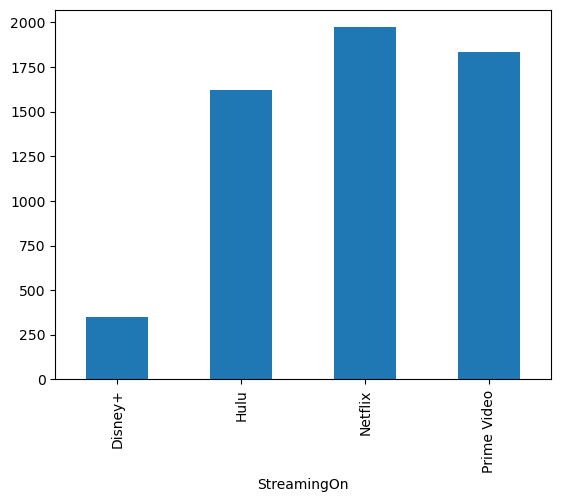

In [36]:
# Now let’s plot the data where the rantings are more than 1 to see the quantity of the tv shows available on each platform
tv_shows_both_ratings = tv_shows_combined[(tv_shows_combined.IMDb > 0) & tv_shows_combined['Rotten Tomatoes'] > 0 ]
tv_shows_combined.groupby('StreamingOn').Title.count().plot(kind= 'bar')

Final Step: Finding Best Streaming Service

In [37]:
figure = []
figure.append(px.violin(tv_shows_both_ratings, x = 'StreamingOn', y = 'IMDb', color='StreamingOn'))
figure.append(px.violin(tv_shows_both_ratings, x = 'StreamingOn', y = 'Rotten Tomatoes', color='StreamingOn'))
fig = make_subplots(rows=2, cols=4, shared_yaxes=True)

for i in range(2):
    for j in range(4):
        fig.add_trace(figure[i]['data'][j], row=i+1, col=j+1)

fig.update_layout(autosize=False, width=800, height=800)        
fig.show()

In [38]:
# Now let’s use a scatter plot to compare the ratings between IMBD and Rotten Tomatoes to compare which streaming platform has the best ratings in both the user rating platforms
px.scatter(tv_shows_both_ratings, x='IMDb',
           y='Rotten Tomatoes',color='StreamingOn')


Conclusion:
By using the violin chart we can observe that:

- Hulu, Netflix, and Amazon Videos all have important data. As content increases, quality decreases for all three.
- Prime Videos has become denser in the top half when looking at IMDB and performs well in cool.
- Disney+ being new, has also been very successful in this area.
Using the scatter plot we can observe that it is quite obvious that Amazon Prime performs very well in the fourth quadrant. Even by using the bar plot, we can observe that Amazon prime had a great quantity of content. So looking at all the streaming platforms we can conclude that Amazon Prime is better in both quality and quantity.